# Simple Baseline — No Transfer Learning, No Custom Head

**Purpose:** Compare basic models trained from scratch vs our custom transfer-learning pipeline.

| | This notebook | main.ipynb |
|--|--|--|
| Pretrained weights | ❌ Random init | ✅ ImageNet |
| Head | Simple FC only | BatchNorm + Dropout + FC |
| Two-phase training | ❌ Single phase | ✅ Freeze → Fine-tune |
| Weight decay | ❌ No | ✅ 1e-4 |
| Dropout in head | ❌ No | ✅ 0.4 |

Both **ResNet-50** and **EfficientNet-B0** are trained sequentially.

## Cell 1 — Imports & Setup

In [1]:
import copy
import json
import logging
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torchvision.models as tv_models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

# ── Path setup ────────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().resolve()
BASE_DIR     = NOTEBOOK_DIR.parent
PROJECT_DIR  = BASE_DIR.parent

for p in [str(PROJECT_DIR), str(BASE_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

from Final_assignment_2.src import config
from Final_assignment_2.src.data_utils import (
    load_and_clean, create_label_encoding, split_data, create_dataloaders,
)
from Final_assignment_2.src.trainer import evaluate_epoch, compute_metrics, TrainingHistory

logging.basicConfig(
    level   = logging.INFO,
    format  = "[%(asctime)s] %(levelname)-8s %(name)s - %(message)s",
    datefmt = "%H:%M:%S",
)
logger = logging.getLogger("simple")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU


## Cell 2 — Configuration

In [2]:
# ── Training schedule ─────────────────────────────────────────────────────
EPOCHS   = 20     # single phase — no freezing
LR       = 1e-3   # same as Phase 1 LR in main.ipynb
PATIENCE = 5      # early stopping patience

torch.manual_seed(config.SEED)
np.random.seed(config.SEED)

print(f"Epochs   : {EPOCHS}")
print(f"LR       : {LR}")
print(f"Patience : {PATIENCE}")
print(f"No pretrained weights | No custom head | No weight decay | No dropout")

Epochs   : 20
LR       : 0.001
Patience : 5
No pretrained weights | No custom head | No weight decay | No dropout


## Cell 3 — Simple Model Definition

- `weights=None` → random initialisation, no ImageNet knowledge
- Head = single `nn.Linear` only — no BatchNorm, no Dropout

In [3]:
def build_simple_model(backbone_name: str, num_classes: int) -> nn.Module:
    """
    Build a basic model with NO pretrained weights and a simple FC head.
    This is the true from-scratch baseline.
    """
    if backbone_name == "resnet50":
        model = tv_models.resnet50(weights=None)       # random init
        in_features = model.fc.in_features             # 2048
        model.fc = nn.Linear(in_features, num_classes) # simple FC, no BN/Dropout

    elif backbone_name == "efficientnet_b0":
        model = tv_models.efficientnet_b0(weights=None)          # random init
        in_features = model.classifier[1].in_features            # 1280
        model.classifier = nn.Linear(in_features, num_classes)   # simple FC

    else:
        raise ValueError(f"Unknown backbone: {backbone_name}")

    total = sum(p.numel() for p in model.parameters())
    print(f"{backbone_name} | params: {total:,} | head: Linear({in_features} → {num_classes})")
    return model


print("build_simple_model defined.")

build_simple_model defined.


## Cell 4 — Simple Training Loop (single phase)

In [4]:
def train_simple(
    model, train_loader, val_loader, device,
    epochs=20, lr=1e-3, patience=5, grad_clip=1.0,
    label_smoothing=0.1,
) -> TrainingHistory:
    """Single-phase training — all layers, same LR, no freezing."""
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # no weight decay
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_loss_h, train_acc_h = [], []
    val_loss_h,   val_acc_h   = [], []

    best_val_loss  = float("inf")
    best_state     = copy.deepcopy(model.state_dict())
    patience_count = 0

    for epoch in range(1, epochs + 1):
        # ── Train ──────────────────────────────────────────────────────
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            total_loss += loss.item() * len(labels)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += len(labels)
        tr_loss = total_loss / total
        tr_acc  = correct / total
        scheduler.step()

        # ── Validate ───────────────────────────────────────────────────
        va_loss, va_acc, _ = evaluate_epoch(model, val_loader, criterion, device)

        train_loss_h.append(tr_loss); train_acc_h.append(tr_acc)
        val_loss_h.append(va_loss);   val_acc_h.append(va_acc)

        logger.info(f"  [{epoch:2d}/{epochs}] "
                    f"train_loss={tr_loss:.4f} acc={tr_acc:.3f} | "
                    f"val_loss={va_loss:.4f} acc={va_acc:.3f}")

        if va_loss < best_val_loss:
            best_val_loss  = va_loss
            best_state     = copy.deepcopy(model.state_dict())
            patience_count = 0
            logger.info(f"    ✓ New best val_loss={best_val_loss:.4f}")
        else:
            patience_count += 1
            logger.info(f"    No improvement ({patience_count}/{patience})")
            if patience_count >= patience:
                logger.info(f"  Early stopping at epoch {epoch}")
                break

    model.load_state_dict(best_state)
    logger.info(f"Done. Best val_loss={best_val_loss:.4f}")
    return TrainingHistory(train_loss_h, train_acc_h, val_loss_h, val_acc_h, phase_boundary=0)


print("train_simple defined.")

train_simple defined.


## Cell 5 — Load Data

In [5]:
df, valid_cats, cat_counts = load_and_clean(
    config.JSON_PATH, config.IMAGE_DIR, config.MIN_SAMPLES
)
label_mapping = create_label_encoding(valid_cats)
splits        = split_data(df, config.TRAIN_RATIO, config.VAL_RATIO, config.SEED)
loaders       = create_dataloaders(
    splits, config.IMAGE_DIR, label_mapping,
    config.BATCH_SIZE, config.NUM_WORKERS, config.PIN_MEMORY,
    config.IMG_SIZE, config.RESIZE_SIZE, config.IMAGENET_MEAN, config.IMAGENET_STD,
)
target_names = [label_mapping.idx2label[i] for i in range(label_mapping.num_classes)]

print(f"Total   : {len(df)} images | {label_mapping.num_classes} classes")
print(f"Train / Val / Test : {len(splits.train_df)} / {len(splits.val_df)} / {len(splits.test_df)}")

[12:19:05] INFO     Final_assignment_2.src.data_utils - Loaded 17362 records
[12:19:09] INFO     Final_assignment_2.src.data_utils - Images verified: 17361 records remain
[12:19:09] INFO     Final_assignment_2.src.data_utils - Kept 28/122 categories with >=100 images → 14791 rows
[12:19:09] INFO     Final_assignment_2.src.data_utils - Split → train:10353  val:2218  test:2220
[12:19:09] INFO     Final_assignment_2.src.data_utils - DataLoaders ready — train:10353  val:2218  test:2220


Total   : 14791 images | 28 classes
Train / Val / Test : 10353 / 2218 / 2220


## Cell 6 — Train ResNet-50 (no pretrained, simple head)

In [6]:
torch.manual_seed(config.SEED)
resnet_simple = build_simple_model("resnet50", label_mapping.num_classes).to(DEVICE)

logger.info("Training simple ResNet-50 from scratch...")
t0 = time.time()
resnet_history = train_simple(
    resnet_simple, loaders.train, loaders.val, DEVICE,
    epochs=EPOCHS, lr=LR, patience=PATIENCE,
    label_smoothing=config.LABEL_SMOOTHING,
)
resnet_time = time.time() - t0
print(f"ResNet-50 training done in {resnet_time/60:.1f} min")

resnet50 | params: 23,565,404 | head: Linear(2048 → 28)


[12:19:14] INFO     simple - Training simple ResNet-50 from scratch...
[12:23:37] INFO     simple -   [ 1/20] train_loss=3.3577 acc=0.087 | val_loss=3.3617 acc=0.029
[12:23:37] INFO     simple -     ✓ New best val_loss=3.3617
[12:28:05] INFO     simple -   [ 2/20] train_loss=3.0190 acc=0.136 | val_loss=3.1303 acc=0.104
[12:28:05] INFO     simple -     ✓ New best val_loss=3.1303
[12:31:32] INFO     simple -   [ 3/20] train_loss=2.8123 acc=0.208 | val_loss=2.6604 acc=0.271
[12:31:32] INFO     simple -     ✓ New best val_loss=2.6604
[12:33:39] INFO     simple -   [ 4/20] train_loss=2.6665 acc=0.257 | val_loss=2.7165 acc=0.211
[12:33:39] INFO     simple -     No improvement (1/5)
[12:35:55] INFO     simple -   [ 5/20] train_loss=2.5338 acc=0.306 | val_loss=3.1812 acc=0.202
[12:35:55] INFO     simple -     No improvement (2/5)
[12:38:09] INFO     simple -   [ 6/20] train_loss=2.4196 acc=0.353 | val_loss=2.6322 acc=0.257
[12:38:09] INFO     simple -     ✓ New best val_loss=2.6322
[12:40:28] 

ResNet-50 training done in 48.9 min


## Cell 7 — Evaluate ResNet-50

In [7]:
criterion = nn.CrossEntropyLoss(label_smoothing=config.LABEL_SMOOTHING)
resnet_results = {}

for split_name, loader in [("Train", loaders.train),
                            ("Val",   loaders.val),
                            ("Test",  loaders.test)]:
    _, _, eval_r = evaluate_epoch(resnet_simple, loader, criterion, DEVICE)
    m = compute_metrics(eval_r, label_mapping.num_classes)
    resnet_results[split_name] = {"metrics": m, "eval": eval_r}
    print(f"ResNet-50 {split_name:<6} | acc={m.accuracy*100:.1f}%  macro_f1={m.macro_f1:.3f}")

r_tr  = resnet_results["Train"]["metrics"].accuracy * 100
r_te  = resnet_results["Test"]["metrics"].accuracy  * 100
print(f"\nResNet-50 Train−Test gap : {r_tr - r_te:.1f}%")

ResNet-50 Train  | acc=65.0%  macro_f1=0.639
ResNet-50 Val    | acc=54.7%  macro_f1=0.509
ResNet-50 Test   | acc=52.2%  macro_f1=0.468

ResNet-50 Train−Test gap : 12.8%


## Cell 8 — Train EfficientNet-B0 (no pretrained, simple head)

In [8]:
torch.manual_seed(config.SEED)
eff_simple = build_simple_model("efficientnet_b0", label_mapping.num_classes).to(DEVICE)

logger.info("Training simple EfficientNet-B0 from scratch...")
t0 = time.time()
eff_history = train_simple(
    eff_simple, loaders.train, loaders.val, DEVICE,
    epochs=EPOCHS, lr=LR, patience=PATIENCE,
    label_smoothing=config.LABEL_SMOOTHING,
)
eff_time = time.time() - t0
print(f"EfficientNet-B0 training done in {eff_time/60:.1f} min")

[13:18:01] INFO     simple - Training simple EfficientNet-B0 from scratch...


efficientnet_b0 | params: 4,043,416 | head: Linear(1280 → 28)


[13:19:41] INFO     simple -   [ 1/20] train_loss=3.1814 acc=0.094 | val_loss=2.8716 acc=0.205
[13:19:41] INFO     simple -     ✓ New best val_loss=2.8716
[13:21:22] INFO     simple -   [ 2/20] train_loss=2.8289 acc=0.189 | val_loss=2.7384 acc=0.169
[13:21:22] INFO     simple -     ✓ New best val_loss=2.7384
[13:23:00] INFO     simple -   [ 3/20] train_loss=2.5989 acc=0.265 | val_loss=2.8960 acc=0.195
[13:23:00] INFO     simple -     No improvement (1/5)
[13:24:39] INFO     simple -   [ 4/20] train_loss=2.3969 acc=0.344 | val_loss=2.4657 acc=0.262
[13:24:39] INFO     simple -     ✓ New best val_loss=2.4657
[13:26:19] INFO     simple -   [ 5/20] train_loss=2.2496 acc=0.398 | val_loss=2.3974 acc=0.323
[13:26:19] INFO     simple -     ✓ New best val_loss=2.3974
[13:28:00] INFO     simple -   [ 6/20] train_loss=2.1407 acc=0.439 | val_loss=2.3148 acc=0.405
[13:28:00] INFO     simple -     ✓ New best val_loss=2.3148
[13:29:40] INFO     simple -   [ 7/20] train_loss=2.0177 acc=0.482 | val_los

EfficientNet-B0 training done in 33.2 min


## Cell 9 — Evaluate EfficientNet-B0

In [9]:
eff_results = {}

for split_name, loader in [("Train", loaders.train),
                            ("Val",   loaders.val),
                            ("Test",  loaders.test)]:
    _, _, eval_r = evaluate_epoch(eff_simple, loader, criterion, DEVICE)
    m = compute_metrics(eval_r, label_mapping.num_classes)
    eff_results[split_name] = {"metrics": m, "eval": eval_r}
    print(f"EfficientNet {split_name:<6} | acc={m.accuracy*100:.1f}%  macro_f1={m.macro_f1:.3f}")

e_tr = eff_results["Train"]["metrics"].accuracy * 100
e_te = eff_results["Test"]["metrics"].accuracy  * 100
print(f"\nEfficientNet-B0 Train−Test gap : {e_tr - e_te:.1f}%")

EfficientNet Train  | acc=82.0%  macro_f1=0.812
EfficientNet Val    | acc=62.5%  macro_f1=0.596
EfficientNet Test   | acc=61.9%  macro_f1=0.590

EfficientNet-B0 Train−Test gap : 20.1%


## Cell 10 — Training Curves (both models)

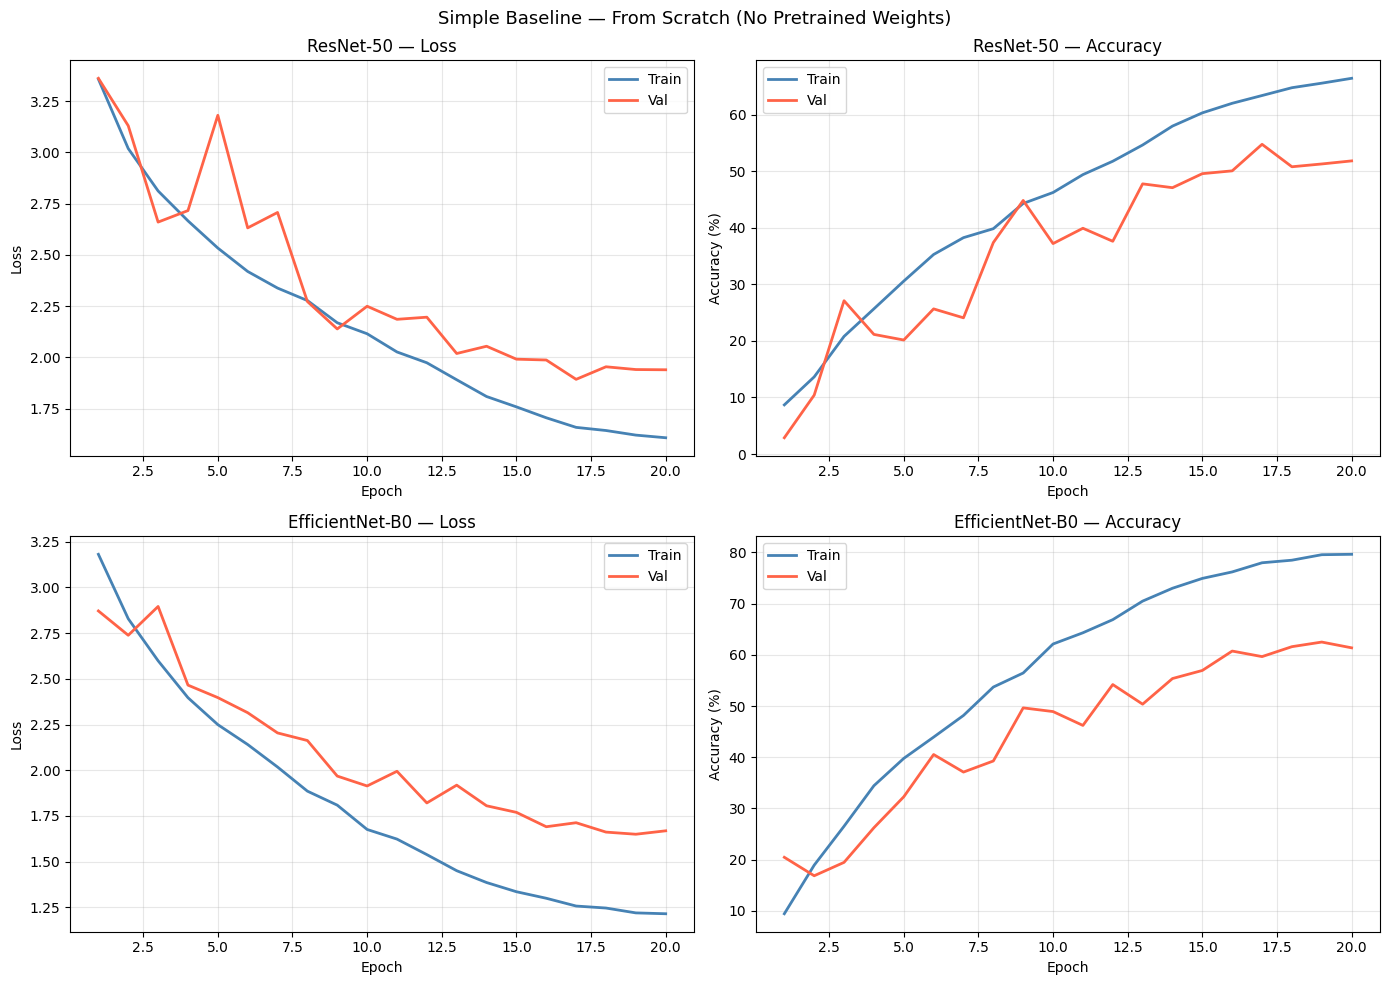

Saved → C:\Users\ekung\Desktop\KU Lueven\semester2\big data\Assignment\Assignment 2\project\Final_assignment_2\outputs\figures\simple_baseline_curves.png


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Simple Baseline — From Scratch (No Pretrained Weights)", fontsize=13)

for row, (history, name) in enumerate([
    (resnet_history, "ResNet-50"),
    (eff_history,    "EfficientNet-B0"),
]):
    epochs = list(range(1, len(history.train_loss) + 1))

    axes[row, 0].plot(epochs, history.train_loss, label="Train", color="steelblue", lw=2)
    axes[row, 0].plot(epochs, history.val_loss,   label="Val",   color="tomato",    lw=2)
    axes[row, 0].set_title(f"{name} — Loss")
    axes[row, 0].set_xlabel("Epoch"); axes[row, 0].set_ylabel("Loss")
    axes[row, 0].legend(); axes[row, 0].grid(True, alpha=0.3)

    axes[row, 1].plot(epochs, [a*100 for a in history.train_acc], label="Train", color="steelblue", lw=2)
    axes[row, 1].plot(epochs, [a*100 for a in history.val_acc],   label="Val",   color="tomato",    lw=2)
    axes[row, 1].set_title(f"{name} — Accuracy")
    axes[row, 1].set_xlabel("Epoch"); axes[row, 1].set_ylabel("Accuracy (%)")
    axes[row, 1].legend(); axes[row, 1].grid(True, alpha=0.3)

plt.tight_layout()
save_path = config.FIGURES_DIR / "simple_baseline_curves.png"
fig.savefig(save_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {save_path}")

## Cell 11 — Final Comparison Table

Simple baseline vs transfer learning results from `main.ipynb`.

In [11]:
# Results from main.ipynb (transfer learning)
transfer_resnet  = {"train": 98.0, "test": 81.5, "gap": 16.5}  # baseline 02_comparison
transfer_eff     = {"train": 88.3, "test": 73.2, "gap": 15.1}  # baseline 02_comparison

print("=" * 70)
print(f"{'Model':<25} {'Train':>8} {'Test':>8} {'Gap':>8} {'Type'}")
print("=" * 70)

print(f"{'ResNet-50 (simple)':<25} {r_tr:>7.1f}% {r_te:>7.1f}% {r_tr-r_te:>7.1f}%  No pretrain, simple FC")
print(f"{'EfficientNet-B0 (simple)':<25} {e_tr:>7.1f}% {e_te:>7.1f}% {e_tr-e_te:>7.1f}%  No pretrain, simple FC")
print("-" * 70)
print(f"{'ResNet-50 (transfer)':<25} {transfer_resnet['train']:>7.1f}% {transfer_resnet['test']:>7.1f}% {transfer_resnet['gap']:>7.1f}%  ImageNet + custom head")
print(f"{'EfficientNet-B0 (transfer)':<25} {transfer_eff['train']:>7.1f}% {transfer_eff['test']:>7.1f}% {transfer_eff['gap']:>7.1f}%  ImageNet + custom head")
print("=" * 70)

print(f"\nResNet-50  gain from transfer learning : +{transfer_resnet['test'] - r_te:.1f}% test accuracy")
print(f"EfficientNet gain from transfer learning: +{transfer_eff['test']    - e_te:.1f}% test accuracy")

Model                        Train     Test      Gap Type
ResNet-50 (simple)           65.0%    52.2%    12.8%  No pretrain, simple FC
EfficientNet-B0 (simple)     82.0%    61.9%    20.1%  No pretrain, simple FC
----------------------------------------------------------------------
ResNet-50 (transfer)         98.0%    81.5%    16.5%  ImageNet + custom head
EfficientNet-B0 (transfer)    88.3%    73.2%    15.1%  ImageNet + custom head

ResNet-50  gain from transfer learning : +29.3% test accuracy
EfficientNet gain from transfer learning: +11.3% test accuracy


## Cell 12 — Classification Reports

In [12]:
print("ResNet-50 Simple — Classification Report (Test)")
print("=" * 60)
print(classification_report(
    resnet_results["Test"]["eval"].labels,
    resnet_results["Test"]["eval"].preds,
    target_names=target_names, digits=3,
))

print("\nEfficientNet-B0 Simple — Classification Report (Test)")
print("=" * 60)
print(classification_report(
    eff_results["Test"]["eval"].labels,
    eff_results["Test"]["eval"].preds,
    target_names=target_names, digits=3,
))

ResNet-50 Simple — Classification Report (Test)
                                      precision    recall  f1-score   support

                            Belville      0.500     0.824     0.622        17
          BrickLink Designer Program      0.133     0.325     0.188        40
                              Castle      0.675     0.634     0.654        82
             Collectible Minifigures      0.333     0.050     0.086       121
                            DREAMZzz      0.229     0.500     0.314        16
                               DUPLO      0.867     0.703     0.776       148
                              Disney      0.324     0.429     0.369        56
                             Friends      0.886     0.759     0.818       133
                               Games      0.739     0.944     0.829        18
                        Harry Potter      0.586     0.531     0.557        96
                     Holiday & Event      0.224     0.448     0.299        58
               

## Cell 13 — Save Checkpoints

In [13]:
for model_obj, name, results, hist, t in [
    (resnet_simple, "resnet50_simple",       resnet_results, resnet_history, resnet_time),
    (eff_simple,    "efficientnet_b0_simple", eff_results,    eff_history,    eff_time),
]:
    torch.save({
        "state_dict":  model_obj.state_dict(),
        "backbone":    name,
        "label2idx":   label_mapping.label2idx,
        "idx2label":   label_mapping.idx2label,
        "num_classes": label_mapping.num_classes,
        "metrics":     results["Test"]["metrics"]._asdict(),
        "history": {
            "train_loss":     hist.train_loss,
            "train_acc":      hist.train_acc,
            "val_loss":       hist.val_loss,
            "val_acc":        hist.val_acc,
            "phase_boundary": hist.phase_boundary,
        },
    }, config.MODELS_DIR / f"{name}.pth")
    print(f"Saved → {config.MODELS_DIR / f'{name}.pth'}")

# Save JSON report
report = {
    "resnet50_simple":       {"train": round(r_tr,1), "test": round(r_te,1), "gap": round(r_tr-r_te,1)},
    "efficientnet_b0_simple":{"train": round(e_tr,1), "test": round(e_te,1), "gap": round(e_tr-e_te,1)},
}
with open(config.REPORTS_DIR / "simple_baseline_report.json", "w") as f:
    json.dump(report, f, indent=2)
print(f"Report saved → {config.REPORTS_DIR / 'simple_baseline_report.json'}")

Saved → C:\Users\ekung\Desktop\KU Lueven\semester2\big data\Assignment\Assignment 2\project\Final_assignment_2\outputs\models\resnet50_simple.pth
Saved → C:\Users\ekung\Desktop\KU Lueven\semester2\big data\Assignment\Assignment 2\project\Final_assignment_2\outputs\models\efficientnet_b0_simple.pth
Report saved → C:\Users\ekung\Desktop\KU Lueven\semester2\big data\Assignment\Assignment 2\project\Final_assignment_2\outputs\reports\simple_baseline_report.json
